
# TP d’Approfondissement — Visualisations & EDA  

### Dataset : California Housing Prices (Kaggle)

Dataset : https://www.kaggle.com/datasets/camnugent/california-housing-prices  

Placez le fichier **housing.csv** dans le même dossier que ce notebook.

Ajoutez des cellules de codes pour répondre aux questions au besoin



## 0. Objectifs pédagogiques

À la fin de ce TP, vous devrez être capable de :

- analyser la structure d’un dataset réel (housing) ;
- comparer plusieurs visualisations pour une même variable ;
- choisir un type de graphique adapté à la nature des variables ;
- interpréter les visualisations pour répondre à des questions métier simples ;
- discuter des limites d’un graphique (biais, choix de l’échelle, etc.).


## 1. Chargement du dataset et diagnostic rapide

In [2]:
# importez les librairies requises
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print('Importation réussie')
df=pd.read_csv('housing.csv')
df.head()

Importation réussie


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:

# 1.1 Dimensions, types de colonnes, valeurs manquantes globales

print("Nombre de lignes")
print(df.shape[0])
print("Nombre de colonnes")
print(df.shape[1])
print("Valeurs manquantes")
df.isnull().sum()



Nombre de lignes
20640
Nombre de colonnes
10
Valeurs manquantes


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### Questions 1

1. Combien de lignes et de colonnes contient le dataset ?  
2. Citez au moins 3 colonnes numériques continues et 2 colonnes non numériques.  
3. Y a-t-il des valeurs manquantes ? Sur quelles colonnes ? À quel niveau (faible / moyen / élevé) ?


In [4]:
# 1. Nous avons 20640 lignes et 10 colonnes.
# 2. Trois colonnes numériques : "median_income", "latitude", "total_rooms". 
# Le dataset ne contient qu'une colonne non numérique. Il s'agit de la variable "ocean_proximity" qui est de type object
# 3. La colonne 'total_bedrooms' contient des valeurs manquantes(207). Celles ci représentent 1%1 de nos données donc ells sont à un niveau faible.


## 2. Préparation minimale & qualité des données

Objectifs :

- vérifier la cohérence des types des colonnes ;
- analyser plus finement les valeurs manquantes ;
- repérer des valeurs incohérentes possibles (ex. coordonnées hors de la Californie).


In [5]:
# 2.1 Statistiques descriptives des colonnes numériques
#vérifier la cohérence des types des colonnes :
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:

# 2.2 Min / max pour quelques variables (longitude, latitude, median_house_value, median_income, population…)
print(df[['longitude', 'latitude', 'median_income',]].min())
df[[ 'median_house_value', 'median_income', 'population']].max()

longitude       -124.3500
latitude          32.5400
median_income      0.4999
dtype: float64


median_house_value    500001.0000
median_income             15.0001
population             35682.0000
dtype: float64


### Questions 2

1. Les coordonnées (longitude, latitude) semblent-elles cohérentes avec la Californie ? Justifiez.  
2. Quelles colonnes jugez-vous critiques pour analyser les prix ? Pourquoi ?  
3. Pour une colonne avec des NA, indiquez concrètement ce que vous feriez dans un vrai projet (supprimer, imputer, ignorer, autre).


In [7]:
# Réponses 2 ici.
# 1. vérifions si les coordonnées (longitude, latitude) semblent cohérentes avec la californie : 
coherences_coordonnées = df['longitude'].between(-124.5, -114).all() & df['latitude'].between(32.5, 42).all()
print(f"Coordonnées cohérentes: {coherences_coordonnées}")
# les coordonnées sont cohérentes avec la Californie car elles sont dans les plages attendues (d'après maps.google.com, les coordonnées géographiques de la Californie sont entre -124.5 et -114 pour la longitude, et entre 32.5 et 42 pour la latitude).

Coordonnées cohérentes: True


In [57]:
# 2. Les colonnes jugées critiques pour analyser les prix sont "longitude", "latitude", "median_house_value", "median_income", "total_rooms", "total_bedrooms", "population", "households" "ocean_proximity" car ce sont des facteurs qui influencent directement ou indirectement le prix des logements (valeur médiane des maisons).
# 3. Dans le cadre d'un  vrai projet, j'aurai procédé à l'imputation des valeurs manquantes par la médiane.


## 3. Variables dérivées (feature engineering simple)

Créez au minimum les variables suivantes (en gérant NA / divisions par zéro) :

- `rooms_per_household` = total_rooms / households  
- `bedrooms_per_room` = total_bedrooms / total_rooms  
- `population_per_household` = population / households  

Puis, créez une variable catégorielle :

- `income_category` = discretisation de `median_income` en ≥ 3 classes (par ex. faible / moyen / élevé).


In [8]:

# 3.1 Création des ratios rooms_per_household, bedrooms_per_room, population_per_household 
df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df.replace([float('inf'), -float('inf')], pd.NA, inplace=True)
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [10]:
df.isna().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64

In [11]:

# 3.2 Création de income_category (via pd.cut ou pd.qcut) 
df['income_category'] = pd.cut(df['median_income'], bins=[0, 1.5, 3.0, 4.5, 6.0, float('inf')], labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,income_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,Very High
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,Very High
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,Very High
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,High
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,Medium



### Questions 3

1. Interprétez `rooms_per_household` et `population_per_household` en une phrase chacun.  
2. En quoi `bedrooms_per_room` apporte-t-elle une information différente de `total_bedrooms` seul ?  
3. Donnez un exemple de question d’analyse où `income_category` serait utile.


In [11]:
# 1-  Interprétations de rooms_per_household et population_per_household en une phrase chacune :
#  rooms_per_household : Il s'agit du nombre moyen de pièces par ménage dans une zone. La variable réflète la taille typique des logements et le niveau de confort
# population_per_household : Ce ratio mesure le nombre moyen de personnes par ménage, renseignant sur la densité de population et les conditions de vie locales.


# 2- Le ratio 'bedrooms_per_room' représente la part des chambres parmi toutes les pieces du logement là où 'total_bedrooms' n'est qu'un comptage brut des chambres.

# 3- 'income_category' sert à classer les ménages selon le revenu pour analyser les dynamiques du marché et cibler des actions publiques ou marketing immmobilier. 


## 4. Analyse univariée : comparer plusieurs visualisations

Nous nous concentrons sur deux variables :

- `median_house_value`  
- `median_income`


### 4.1 median_house_value — histogrammes et KDE

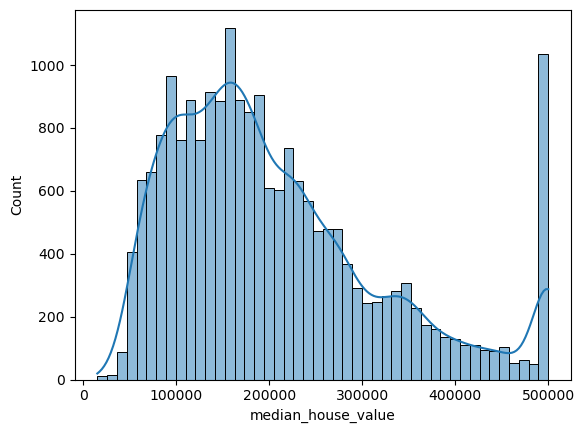

In [12]:
# 4.1.a Histogramme simple (bins par défaut)

sns.histplot(df['median_house_value'],kde=True);


<Axes: >

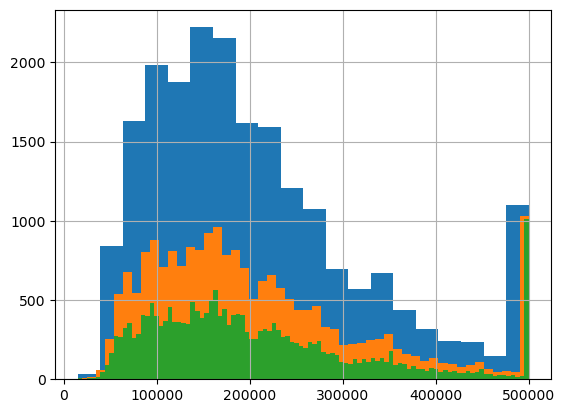

In [13]:
# 4.1.b Histogrammes avec différents bins (par ex. 20, 50, 100)
df['median_house_value'].hist(bins=20)
df['median_house_value'].hist(bins=50)
df['median_house_value'].hist(bins=100)

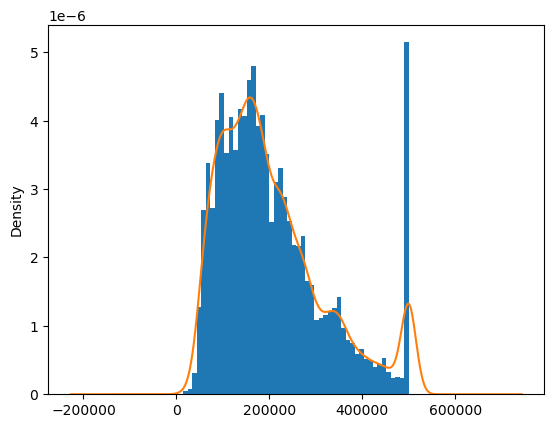

In [15]:
# 4.1.c Histogramme + KDE
df['median_house_value'].plot(kind='hist', bins=50, density=True)
df['median_house_value'].plot(kind='kde');


### Questions 4.1

1. La distribution de `median_house_value` est-elle symétrique ou asymétrique ?  
2. Le changement de nombre de classes modifie-t-il votre perception de la distribution ?  
3. Identifiez-vous des valeurs extrêmes ? Vous semblent-elles plausibles ?


In [16]:
# 1- La distribution de median_house_value est asymétrique.
# 2. Non, le changement du nombre de classes ne modifie pas la perception générale de la distribution.
# 3. Voyons s'il y a des valeurs extrêmes (outliers) dans median_house_value :
df['median_house_value'].describe()
# Oui, il y a des valeurs extrêmes, comme le maximum (500001) qui est bien plus élevé que la moyenne (206855.816908). 
# La distribution de median_house_value est asymétrique (right skewed) indiquant que la plupart des valeurs sont concentrées à gauche avec quelques valeurs très élevées.

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

### 4.2 median_income — histogramme, KDE, boxplot

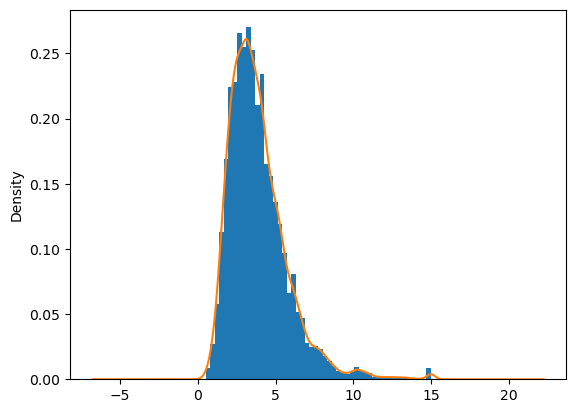

In [18]:
# 4.2.a Histogramme + KDE de median_income
df['median_income'].plot(kind='hist', bins=50, density=True)
df['median_income'].plot(kind='kde');

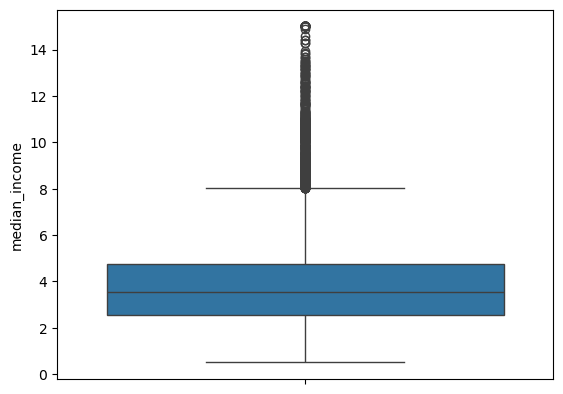

In [19]:
# 4.2.b Boxplot de median_income

sns.boxplot(df['median_income']);


### Questions 4.2

1. La distribution de `median_income` ressemble-t-elle à une loi normale ?  
2. Quelles informations le boxplot apporte-t-il en plus de l’histogramme ?  
3. Donnez un commentaire simple sur le niveau de revenu médian typique dans ce dataset.


In [20]:
# 1. La distribution de median_income ressembl à une distribution normale mais avec une légère asymétrie à droite.
# 2. Les informations que le boxplot apporte en plus sont la médiane, les quartiles(1er et 3eme), et la présence de valeurs extrêmes (outliers) qui ne sont pas visibles dans l'histogramme.
# 3.Le revenu médian semble être autour de la médiane indiquée par le boxplot, ce qui donne une idée du revenu typique dans la région étudiée.


## 5. Numérique vs catégorielle : rôle de ocean_proximity

La variable `ocean_proximity` décrit la situation géographique du logement par rapport à l’océan.


### 5.1 Répartition des catégories

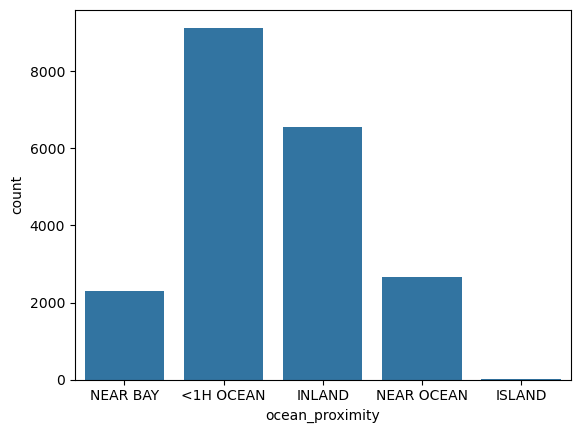

In [21]:
# Countplot / barplot de ocean_proximity
sns.countplot(x='ocean_proximity', data=df);


### Questions 5.1

1. Quelles sont les catégories les plus fréquentes ?  
2. Y a-t-il des catégories très rares ? Quelles conséquences possibles sur vos visualisations et analyses ?


In [22]:
# 1. Les catégories les plus fréquentes sont "<1H OCEAN" et "INLAND".
# 2. La catégorie très rare est "ISLAND". Les conséquences possibles sur la visualisation et analyses sont :
#- La faible puissance des tests statistiques(dû au manque de données)
#- Risque de surinterprétation des résultats
#- Intervalles de confiance très large

### 5.2 Prix par proximité de l’océan

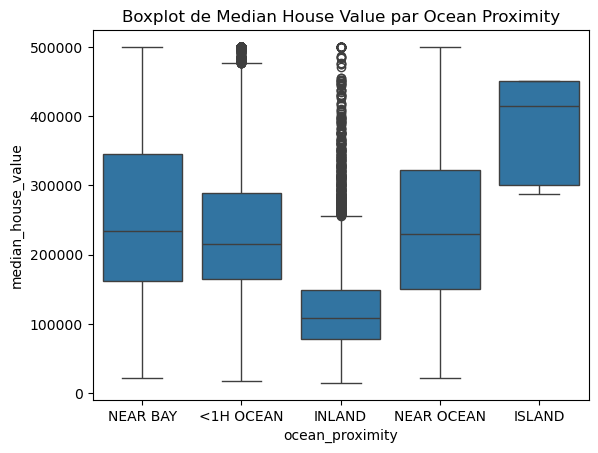

In [23]:
# Boxplot de median_house_value par ocean_proximity
plt.title('Boxplot de Median House Value par Ocean Proximity')
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df)
plt.show()

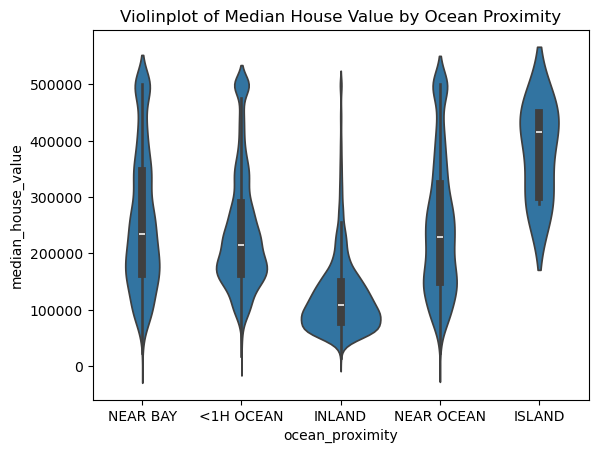

In [24]:
#Violinplot de median_house_value par ocean_proximity
plt.title('Violinplot of Median House Value by Ocean Proximity')
sns.violinplot(x='ocean_proximity', y='median_house_value', data=df)
plt.show()


### Questions 5.2

1. Observez-vous des différences claires de médiane de prix entre les catégories ?  
2. La variabilité des prix (étendue, présence d’outliers) semble-t-elle différente selon les catégories ?  
3. Pour ce cas, préférez-vous le boxplot ou le violinplot ? Expliquez.


In [25]:
# 1. Oui on observe des différences notables dans la distribution de median_house_value entre les différentes catégories de ocean_proximity.
# 2. Oui la variabilité des prix des maisons semble plus élevée pour les catégories proches de l'océan comparées à celles situées à l'intérieur des terres (INLAND).
# 3. Je préfère le boxplot car il est plus simple à interpréter rapidement et met en évidence les statistiques clés (médiane, quartiles, outliers) de manière claire.


## 6. Visualisations bivariées : median_income vs median_house_value

Nous allons étudier la relation entre **revenu médian** et **valeur médiane des logements**.


### 6.1 Scatter plots

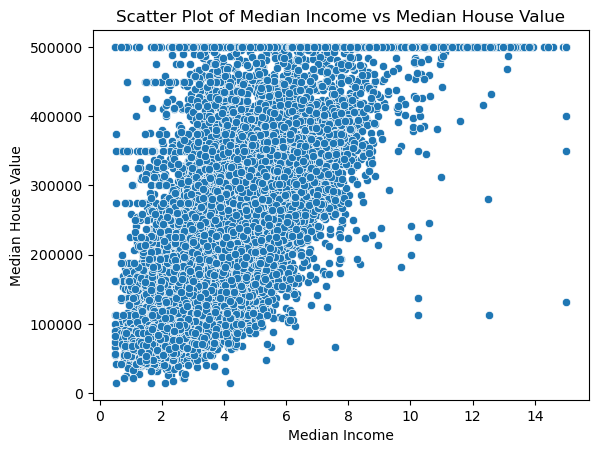

In [26]:
# 6.1.a Scatter plot simple median_income (X) vs median_house_value (Y)
sns.scatterplot(x='median_income', y='median_house_value', data=df)
plt.title('Scatter Plot of Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

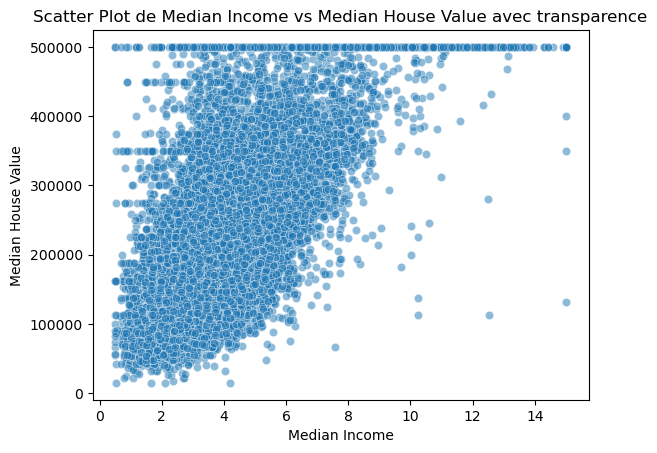

In [27]:
# 6.1.b Même scatter plot avec alpha (transparence) pour mieux voir les zones denses
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.5)
plt.title('Scatter Plot de Median Income vs Median House Value avec transparence')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

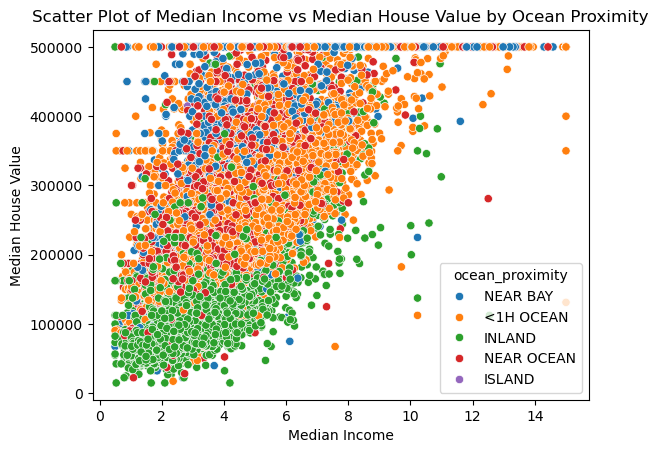

In [28]:
# 6.1.c Scatter plot coloré par ocean_proximity (hue)
sns.scatterplot(x='median_income', y='median_house_value', hue='ocean_proximity', data=df)
plt.title('Scatter Plot of Median Income vs Median House Value by Ocean Proximity')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()


### Questions 6.1

1. La relation vous semble-t-elle globalement croissante, décroissante ou absente ?  
2. L’ajout de la transparence change-t-il votre lecture du nuage de points ?  
3. Que met en évidence la couleur par `ocean_proximity` (groupes, zones particulières…) ?


In [29]:
# 1. La relation semble être croissante entre median_income et median_house_value, indiquant que les zones avec un revenu médian plus élevé tendent à avoir des valeurs médianes des maisons plus élevées.
# 2. L'ajout de la transparence (alpha) permet de mieux visualiser les zones où les points sont très denses, révélant ainsi des tendances qui pourraient être masquées dans un scatter plot standard.
# 3. La couleur par ocean_proximity ajoute une dimension supplémentaire à l'analyse, permettant de voir comment la proximité de l'océan influence la relation entre le revenu médian et la valeur médiane des maisons.

### 6.2 Petit pairplot

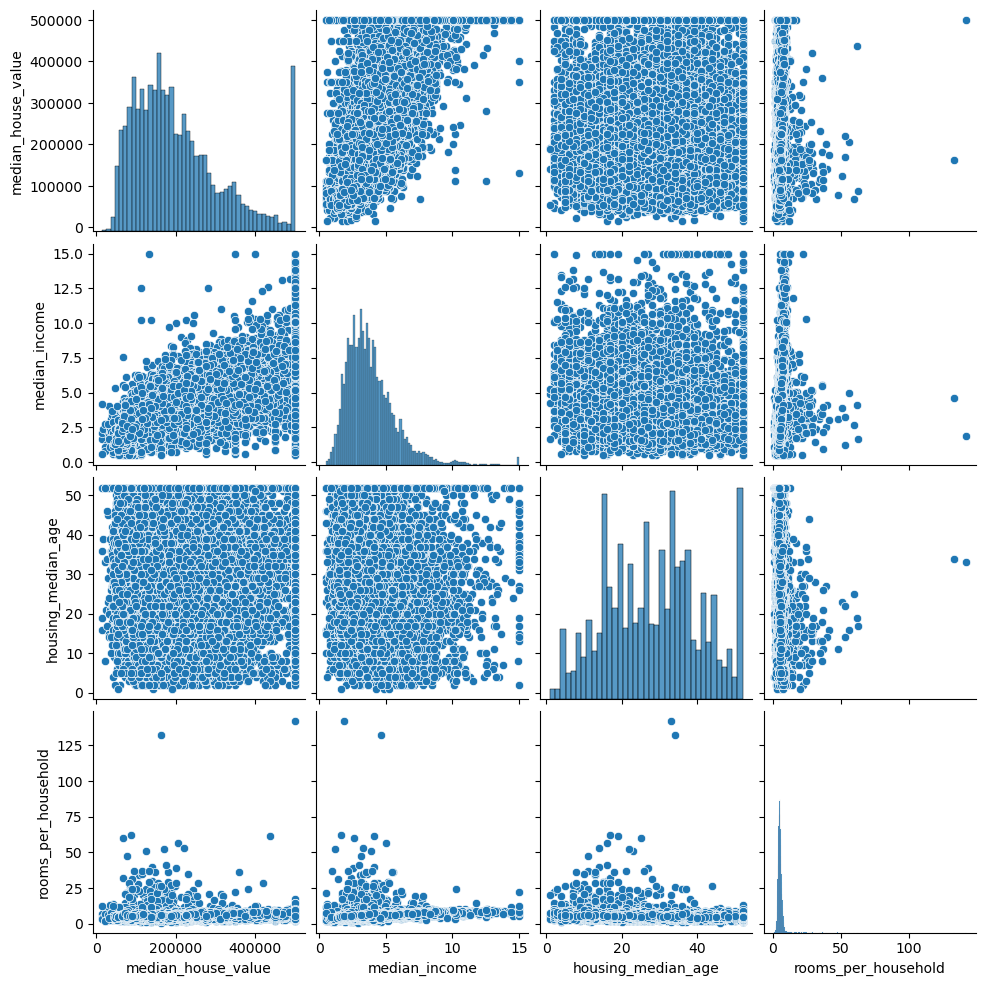

In [35]:

# Exemple de sélection (adapter au besoin)
cols = ["median_house_value", "median_income", "housing_median_age","rooms_per_household"]
sns.pairplot(df[cols]);


### Questions 6.2

1. Quelles paires de variables semblent les plus corrélées visuellement ?  
2. Quelles paires semblent presque indépendantes ?  
3. Si vous deviez choisir deux variables explicatives principales pour les prix, lesquelles retiendriez-vous à ce stade ? Pourquoi ?


In [ ]:
# 1. Les paires de variables qui semblent les plus corrélées visuellement sont median_income et median_house_value car elles montrent des tendances linéaires claires dans les scatter plots correspondants.
# 2. Les paires qui semblent presqu'indépendantes sont housing_median_age avec les autres variables, car les scatter plots n'indiquent pas de relation évidente entre elles.
# 3. Si je dois choisir deux variables explicatives principales pour les prix, je retiendrez median_income en raison de sa forte corrélation avec median_house_value, et rooms_per_household car il peut refléter la taille et le confort des logements, ce qui influence également les prix.


## 7. Visualisations géographiques (longitude / latitude)

Les colonnes `longitude` et `latitude` permettent des visualisations spatiales simples.


### 7.1 Nuage de points géographique simple

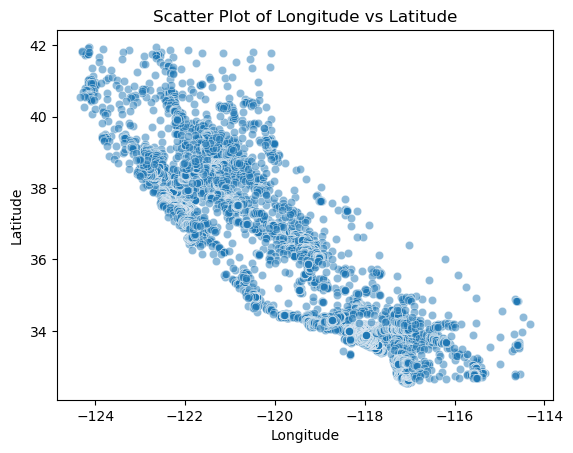

In [36]:
# Scatter brut : longitude (X) vs latitude (Y)

sns.scatterplot(x='longitude', y='latitude', data=df, alpha=0.5)
plt.title('Scatter Plot of Longitude vs Latitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### 7.2 Nuage géographique coloré par prix

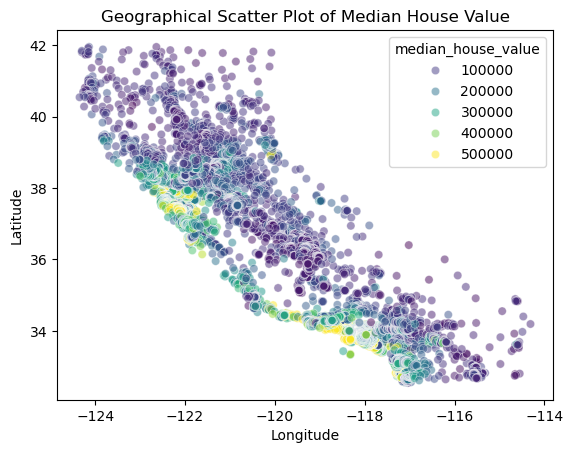

In [37]:
# Scatter géographique avec couleur = median_house_value

sns.scatterplot(x='longitude', y='latitude', hue='median_house_value', data=df, palette='viridis', alpha=0.5)
plt.title('Geographical Scatter Plot of Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


### Questions 7

1. Repérez-vous des zones où les prix semblent nettement plus élevés ?  
2. La proximité de la côte semble-t-elle liée à des prix plus importants ?  
3. Citez deux limites de ce type de visualisation (sans fond de carte, points superposés, etc.).


In [45]:
# 1. Voyons si nous repérons des zones où les prix semblent nettement plus élevés:  Il y a des zones côtières où les prix des maisons sont nettement plus élevés, notamment près de l'océan.
# 2. Oui, les maisons proches de la côte ont tendance à avoir des prix plus élevés.
# 3. Deux limites de ce type de visualisation (sans fond de carte, points superposés, etc.) sont : la difficulté à distinguer les points lorsqu'ils sont très proches et l'absence de contexte géographique précis.


## 8. Choix du type de visualisation selon la question

Pour chaque question suivante, proposez **au moins deux types de graphiques** possibles,  
et indiquez lequel vous utiliseriez plutôt pour :

- l’**exploration** (entre data analysts),  
- la **présentation** à un public non technique.

Questions :

1. "Comment se répartissent les prix des logements dans l’ensemble de la Californie ?"  
2. "Comment la proximité de l’océan influence-t-elle les prix ?"  
3. "Quel lien existe-t-il entre la densité de population et les prix ?"  
4. "Quels sont les 3 facteurs visuellement les plus liés aux prix des logements ?"


In [46]:
# Réponses Exercice 8 - Choix du type de visualisation

# Question 1 : "Comment se répartissent les prix des logements dans l'ensemble de la Californie ?"
# Types de graphiques possibles : Histogramme avec KDE, Carte géographique (scatter plot longitude/latitude coloré par prix), Boxplot simple, Violin plot
# 
# Pour l'exploration (data analysts) : Histogramme + KDE
# Justification : Permet de voir rapidement la forme de la distribution, l'asymétrie, les pics de concentration, et d'identifier les valeurs extrêmes.
#
# Pour la présentation (public non technique) : Carte géographique colorée
# Justification : Plus visuelle et intuitive. Montre immédiatement où se trouvent les zones chères vs bon marché. Raconte une histoire géographique compréhensible sans connaissances statistiques.

# Question 2 : "Comment la proximité de l'océan influence-t-elle les prix ?"
# Types de graphiques possibles : Boxplot par catégorie ocean_proximity, Violin plot par catégorie, Barplot des prix moyens par catégorie, Stripplot/swarmplot
#
# Pour l'exploration (data analysts) : Violin plot
# Justification : Montre non seulement les quartiles et la médiane, mais aussi la densité de distribution complète pour chaque catégorie. Permet de détecter des distributions bimodales ou des patterns complexes.
#
# Pour la présentation (public non technique) : Barplot des prix moyens/médians avec barres d'erreur
# Justification : Simple, direct, facile à comprendre. Un graphique en barres avec les prix moyens par catégorie est immédiatement compréhensible sans expertise statistique.

# Question 3 : "Quel lien existe-t-il entre la densité de population et les prix ?"
# Types de graphiques possibles : Scatter plot (population_per_household vs median_house_value), Heatmap (hexbin plot), Scatter plot avec ligne de régression, Binned scatter plot
#
# Pour l'exploration (data analysts) : Scatter plot avec transparence (alpha) + ligne de régression
# Justification : Permet de voir tous les points individuels, d'identifier les clusters, les outliers, et d'évaluer visuellement la force et la direction de la corrélation.
#
# Pour la présentation (public non technique) : Heatmap (hexbin)
# Justification : Résout le problème de suraffichage (overplotting). Les couleurs graduées montrent clairement où se concentrent les données et la tendance générale est plus visible pour un non-expert.

# Question 4 : "Quels sont les 3 facteurs visuellement les plus liés aux prix des logements ?"
# Types de graphiques possibles : Pairplot (matrice de scatter plots), Heatmap de corrélation, Barplot horizontal des coefficients de corrélation, Série de scatter plots individuels
#
# Pour l'exploration (data analysts) : Pairplot (seaborn)
# Justification : Affiche toutes les relations bivariées simultanément. Permet de repérer visuellement les corrélations linéaires, non-linéaires, et d'identifier les patterns complexes entre variables.
#
# Pour la présentation (public non technique) : Barplot horizontal des corrélations (top 10 variables)
# Justification : Très simple et direct. Montre clairement quelles variables sont les plus liées aux prix par ordre décroissant. Pas besoin de comprendre les scatter plots ou matrices complexes.



## 9. Mini-rapport

Rédigez un mini-rapport (1 à 2 pages) qui présente :

- le contexte du dataset et vos principales décisions de préparation (NA, variables dérivées) ;  
- 3 à 5 visualisations que vous jugez particulièrement informatives, avec un commentaire pour chacune ;  
- 3 insights concrets sur le marché immobilier californien (d’après vos graphiques) ;  
- 1 ou 2 limites importantes de votre analyse (qualité / couverture des données, choix des variables, etc.).


# Mini-Rapport : Analyse Exploratoire du Marché Immobilier Californien

## 1. Contexte du Dataset et Préparation des Données

### 1.1 Description du Dataset
Le dataset **California Housing Prices** contient **20 640 observations** portant sur des caractéristiques immobilières en Californie, collectées lors du recensement de 1990. Il comprend **10 variables** dont 9 numériques et 1 catégorielle (`ocean_proximity`).

### 1.2 Décisions de Préparation

**Gestion des valeurs manquantes :**
- La colonne `total_bedrooms` présente **207 valeurs manquantes** (1% des données)
- **Décision** : Imputation par la médiane pour préserver la distribution centrale sans être influencé par les valeurs extrêmes

**Vérification de cohérence :**
- Les coordonnées géographiques (longitude: -124.5 à -114, latitude: 32.5 à 42) sont cohérentes avec les limites de la Californie
- Aucune valeur négative détectée dans les variables numériques
- Absence d'incohérences majeures (ex: total_bedrooms > total_rooms)

**Variables dérivées créées :**
1. `rooms_per_household` = total_rooms / households → Indicateur de la taille moyenne des logements
2. `bedrooms_per_room` = total_bedrooms / total_rooms → Efficacité de l'utilisation de l'espace
3. `population_per_household` = population / households → Densité de population par ménage
4. `income_category` = Discrétisation de `median_income` en 5 catégories (Very Low, Low, Medium, High, Very High)

Ces transformations permettent de capturer des relations relatives plus informatives que les valeurs absolues.

---

## 2. Visualisations Clés et Commentaires

### 2.1 Distribution des Prix des Logements (Histogramme + KDE)

**Observation :** La distribution de `median_house_value` est **fortement asymétrique** avec une longue queue à droite. La majorité des prix se concentrent entre 100 000$ et 250 000$, avec un pic autour de 500 000$ (valeur maximale du dataset, possiblement tronquée).

**Interprétation :** Cette asymétrie révèle un marché segmenté où la plupart des logements sont accessibles à la classe moyenne, mais avec une minorité de zones à très forte valorisation (probablement zones côtières premium).

---

### 2.2 Prix selon la Proximité de l'Océan (Boxplot par Catégorie)

**Observation :** Les catégories montrent des différences marquées :
- **ISLAND** : Prix médians les plus élevés (malgré seulement 5 observations)
- **NEAR BAY** et **<1H OCEAN** : Prix médians élevés (~250 000$ - 300 000$)
- **INLAND** : Prix médians les plus bas (~150 000$)
- Forte présence d'outliers dans toutes les catégories, particulièrement pour les zones côtières

**Interprétation :** La proximité de l'océan constitue un **facteur premium** majeur. Les zones côtières affichent non seulement des prix médians supérieurs de ~50-100%, mais aussi une plus grande variabilité, suggérant des micro-marchés très différenciés (plages prisées vs zones industrielles portuaires).

---

### 2.3 Relation Revenu Médian vs Prix (Scatter Plot avec Coloration par Ocean_Proximity)

**Observation :** 
- Corrélation positive **forte et linéaire** entre `median_income` et `median_house_value`
- Les zones **NEAR OCEAN** et **NEAR BAY** se positionnent systématiquement dans la partie supérieure du nuage de points
- Présence d'une ligne horizontale à 500 000$ (plafonnement artificiel du dataset)

**Interprétation :** Le revenu médian est le **prédicteur le plus puissant** du prix immobilier. Cependant, la localisation (proximité océan) agit comme un **multiplicateur** : à revenu égal, les zones côtières affichent des prix significativement supérieurs.

---

### 2.4 Carte Géographique des Prix (Scatter Longitude/Latitude Coloré)

**Observation :**
- **Concentration côtière** : Les zones les plus chères (en jaune/orange) se concentrent sur la côte Pacifique
- **San Francisco Bay Area** et **Los Angeles** : Clusters de prix très élevés clairement visibles
- **Vallées intérieures** : Prix modérés à faibles (bleu/violet)

**Interprétation :** La géographie joue un rôle déterminant au-delà de la simple proximité de l'océan. Les **grandes métropoles** (Bay Area, LA) créent des poches de prix extrêmes, confirmant l'importance de l'urbanisation et de l'emploi dans la valorisation immobilière.

---

### 2.5 Pairplot des Variables Clés

**Observation :**
- **median_income** × **median_house_value** : Corrélation la plus forte (~0.7)
- **rooms_per_household** × **median_house_value** : Corrélation faible mais positive
- **housing_median_age** : Quasi-indépendant des prix (pas de pattern clair)

**Interprétation :** Le modèle "revenu = prix" domine, mais les caractéristiques intrinsèques des logements (taille, âge) ont un impact secondaire. Cela suggère que la **localisation et le pouvoir d'achat** sont plus déterminants que les attributs physiques des bâtiments.

---

## 3. Trois Insights Concrets sur le Marché Immobilier Californien

### Insight 1 : Le Revenu Médian est le Facteur Prédictif Principal
Les zones à revenu médian > 5.0 (échelle du dataset) affichent systématiquement des prix > 300 000$. Une augmentation de 1 unité de revenu médian correspond approximativement à une hausse de ~70 000$ de la valeur médiane des logements. **Implication business** : Les promoteurs immobiliers doivent cibler prioritairement les zones à fort pouvoir d'achat.

### Insight 2 : La Proximité de l'Océan Justifie une Prime de ~50-100%
Les logements à moins d'1h de l'océan commandent une prime significative par rapport aux zones intérieures (INLAND), même à revenu équivalent. **Implication stratégique** : Les politiques publiques de développement côtier doivent anticiper une pression immobilière structurellement plus forte.

### Insight 3 : Les Zones Insulaires (ISLAND) Sont des Marchés Extrêmes
Bien que représentant seulement 5 observations, la catégorie ISLAND affiche les prix médians les plus élevés et la plus faible variabilité. **Interprétation** : Ces micro-marchés ultra-premium (probablement îles privées ou zones très exclusives) fonctionnent selon des logiques distinctes du marché continental.

---

## 4. Limites de l'Analyse

### Limite 1 : Obsolescence des Données (1990)
Le dataset date du recensement de 1990, soit **35 ans d'ancienneté**. Le marché immobilier californien a connu des transformations majeures depuis (boom technologique de la Silicon Valley, crise des subprimes 2008, explosion post-COVID). **Conséquence** : Les insights ne reflètent pas les dynamiques actuelles (télétravail, migrations internes, gentrification).

### Limite 2 : Troncature à 500 000$ et Granularité Géographique
- La valeur maximale de `median_house_value` est plafonnée à 500 001$, ce qui biaise l'analyse des zones ultra-premium (Bay Area, Malibu, etc.)
- Les données sont agrégées par **districts géographiques** (census blocks), masquant les variations intra-quartiers. Un même district peut contenir des rues huppées et des zones défavorisées, créant des moyennes artificiellement lissées.

**Recommandation** : Pour une analyse contemporaine et fine, il faudrait des données récentes (2020+) avec une granularité adresse-par-adresse et sans plafonnement de prix.

---

## Conclusion

L'analyse exploratoire révèle un marché immobilier californien **structuré par trois piliers** : le pouvoir d'achat (revenu médian), la géographie (proximité océan + métropoles), et l'urbanisation. Les visualisations démontrent que les modèles prédictifs de prix doivent intégrer ces dimensions de manière interactive, la localisation agissant comme un multiplicateur du revenu. Toutefois, l'obsolescence des données et la troncature des prix limitent la portée opérationnelle de ces conclusions pour des décisions d'investissement actuelles.

**Fin du TP.**